# Environmental Effect on Egg Production - MCDM + ML Framework
## Multi-Criteria Analysis with XGBoost, KNN & Naive Bayes

**Objective:** Analyze environmental factors affecting egg production using MCDM framework
**Models:** XGBoost Regressor, K-Nearest Neighbors, Gaussian Naive Bayes
**Prediction Target:** Total Egg Production (units)


## Section 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load dataset
# Note: Replace path with your local Egg_Production.csv file
try:
    df = pd.read_csv('Egg_Production.csv')

except:
    print("⚠️  Egg_Production.csv not found in workspace")
    print("Please download from: https://www.kaggle.com/datasets/...")
    df = None

if df is not None:
    print("="*80)
    print("ENVIRONMENTAL EFFECT ON EGG PRODUCTION - MCDM + ML ANALYSIS")
    print("="*80)
    print(f"\nDataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"\nFirst rows:\n{df.head()}")
    print(f"\nData types:\n{df.dtypes}")
    print(f"\nMissing values:\n{df.isnull().sum()}")
    print(f"\nBasic statistics:\n{df.describe()}")


ENVIRONMENTAL EFFECT ON EGG PRODUCTION - MCDM + ML ANALYSIS

Dataset shape: (481, 8)
Columns: ['Amount_of_chicken', 'Amount_of_Feeding', 'Ammonia', 'Temperature', 'Humidity', 'Light_Intensity', 'Noise', 'Total_egg_production']

First rows:
   Amount_of_chicken  Amount_of_Feeding  Ammonia  Temperature  Humidity  \
0               2728                170     14.4         29.3      51.7   
1               2728                175     17.6         29.3      52.3   
2               2728                175     15.0         29.3      52.5   
3               2728                170     15.0         29.3      49.7   
4               2728                170     15.9         29.2      51.4   

   Light_Intensity  Noise  Total_egg_production  
0              364    214                  2115  
1              369    235                  1958  
2              373    237                  1990  
3              372    240                  2015  
4              381    237                  2112  

Data typ

## Section 2: Define Criteria & Prepare Data

In [2]:
if df is not None:
    # Identify numeric columns (environmental factors)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Assuming 'Total_egg_production' or similar is the target
    # Adjust column name based on your data
    target_col = [col for col in numeric_cols if 'production' in col.lower() or 'egg' in col.lower()]
    if target_col:
        target_col = target_col[0]
    else:
        target_col = numeric_cols[-1]  # Use last numeric column as target
    
    # Select criteria (all numeric columns except target)
    criteria_columns = [col for col in numeric_cols if col != target_col and col != 'Ammonia']
    
    print("\nCRITERIA SELECTION FOR MCDM:")
    print(f"Criteria: {len(criteria_columns)} environmental factors")
    print(f"Target: {target_col}")
    print(f"\nCriteria columns: {criteria_columns}")
    
    # Define criteria types (cost/profit)
    # General assumption: higher temperature/humidity can be beneficial or harmful
    criteria_types = {}
    for col in criteria_columns:
        # Default: most environmental factors are "cost" (extremes are bad)
        criteria_types[col] = 'cost'
    
    # Adjust for known beneficial factors
    for col in criteria_columns:
        if any(x in col.lower() for x in ['temperature', 'humidity', 'light']):
            criteria_types[col] = 'cost'  # Extremes harmful
        elif any(x in col.lower() for x in ['feed', 'protein', 'nutrition']):
            criteria_types[col] = 'profit'  # More is better
    
    print("\nCriteria Types:")
    for col, ctype in criteria_types.items():
        symbol = "↑" if ctype == "profit" else "↓"
        print(f"  {col:30s} | {ctype:10s} | {symbol}")
    
    # Prepare MCDM data
    df_mcdm = df[criteria_columns + [target_col]].dropna()
    print(f"\nMCDM dataset (after removing NAs): {df_mcdm.shape}")
    
    # Normalize data to [0, 1]
    def normalize_matrix(data, criteria_types):
        normalized_data = data.copy()
        for criterion in data.columns:
            min_val = data[criterion].min()
            max_val = data[criterion].max()
            range_val = max_val - min_val
            
            if range_val == 0:
                normalized_data[criterion] = 0.5
            else:
                if criteria_types.get(criterion, 'cost') == 'cost':
                    normalized_data[criterion] = (max_val - data[criterion]) / range_val
                else:  # profit
                    normalized_data[criterion] = (data[criterion] - min_val) / range_val
        return normalized_data
    
    X = df_mcdm[criteria_columns].copy()
    X_normalized = normalize_matrix(X, criteria_types)
    y = df_mcdm[target_col].values
    
    print(f"\n✓ Data normalized to [0, 1]")
    print(f"\nNormalized preview:\n{X_normalized.head()}")



CRITERIA SELECTION FOR MCDM:
Criteria: 6 environmental factors
Target: Total_egg_production

Criteria columns: ['Amount_of_chicken', 'Amount_of_Feeding', 'Temperature', 'Humidity', 'Light_Intensity', 'Noise']

Criteria Types:
  Amount_of_chicken              | cost       | ↓
  Amount_of_Feeding              | profit     | ↑
  Temperature                    | cost       | ↓
  Humidity                       | cost       | ↓
  Light_Intensity                | cost       | ↓
  Noise                          | cost       | ↓

MCDM dataset (after removing NAs): (481, 7)

✓ Data normalized to [0, 1]

Normalized preview:
   Amount_of_chicken  Amount_of_Feeding  Temperature  Humidity  \
0           0.160377           0.000000     0.771429  0.317073   
1           0.160377           0.166667     0.771429  0.243902   
2           0.160377           0.166667     0.771429  0.219512   
3           0.160377           0.000000     0.771429  0.560976   
4           0.160377           0.000000     0.80

## Section 3: Calculate MCDM Weights

CALCULATING OBJECTIVE WEIGHTS

Weight Summary:
                      STD  Entropy  CRITIC   MEREC  Compromise
Amount_of_chicken  0.2552   0.3952  0.2449  0.2142      0.2774
Amount_of_Feeding  0.1786   0.1777  0.1122  0.1631      0.1579
Temperature        0.1611   0.0580  0.2098  0.0000      0.1072
Humidity           0.1412   0.0850  0.1319  0.1484      0.1266
Light_Intensity    0.1270   0.0994  0.1181  0.2073      0.1379
Noise              0.1369   0.1847  0.1832  0.2670      0.1930


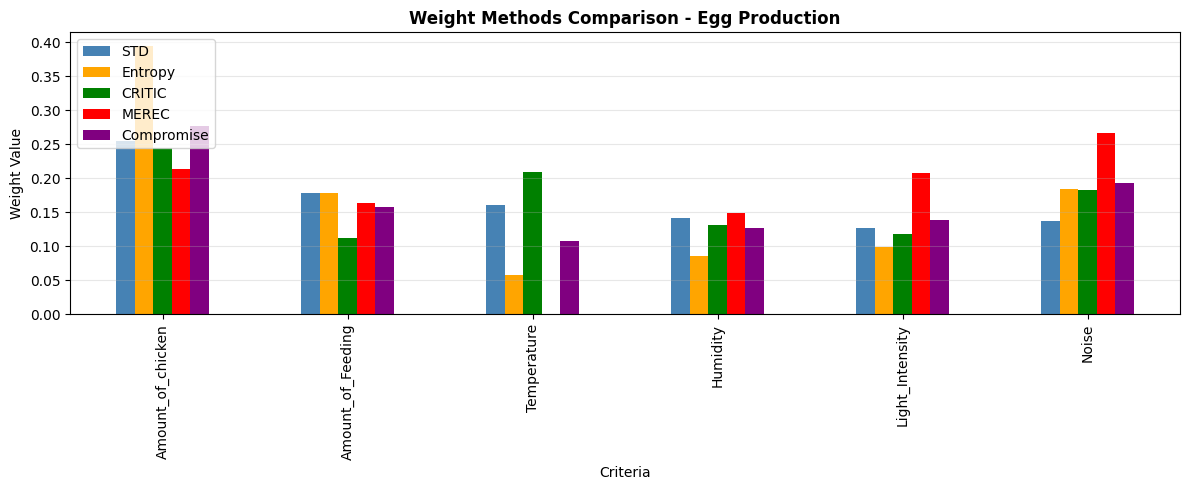


✓ Weights calculated!


In [3]:
if df is not None:
    # Weight calculation methods
    def calc_weights_std(data):
        """Standard Deviation"""
        std_vals = data.std(ddof=0)
        return std_vals / std_vals.sum()

    def calc_weights_entropy(data):
        """Entropy method"""
        n = len(data)
        pij = data / data.sum()
        pij = pij.replace(0, 1e-10)
        entropy = -(1 / np.log(n)) * (pij * np.log(pij)).sum()
        divergence = 1 - entropy
        return divergence / divergence.sum()

    def calc_weights_critic(data):
        """CRITIC method"""
        std_vals = data.std(ddof=0)
        corr_matrix = data.corr().abs()
        corr_sum = corr_matrix.sum() - 1
        critic_w = std_vals * corr_sum
        return critic_w / critic_w.sum()

    def calc_weights_merec(data):
        """MEREC method"""
        n_alt = len(data)
        n_crit = len(data.columns)
        removal_effects = []
        
        for j in range(n_crit):
            cols_except_j = [col for col in data.columns if col != data.columns[j]]
            if len(cols_except_j) > 0:
                data_without_j = data[cols_except_j]
                perf_without_j = data_without_j.sum(axis=1) / len(cols_except_j)
                removal_effect = np.log(perf_without_j.sum() / n_alt)
            else:
                removal_effect = 0
            removal_effects.append(removal_effect)
        
        removal_effects = np.array(removal_effects)
        removal_effects = removal_effects - removal_effects.min()
        if removal_effects.sum() > 0:
            return pd.Series(removal_effects / removal_effects.sum(), index=data.columns)
        return pd.Series(np.ones(n_crit) / n_crit, index=data.columns)

    print("="*80)
    print("CALCULATING OBJECTIVE WEIGHTS")
    print("="*80)

    w_std = calc_weights_std(X_normalized)
    w_entropy = calc_weights_entropy(X_normalized)
    w_critic = calc_weights_critic(X_normalized)
    w_merec = calc_weights_merec(X_normalized)

    weights_df = pd.DataFrame({
        'STD': w_std,
        'Entropy': w_entropy,
        'CRITIC': w_critic,
        'MEREC': w_merec
    })

    w_compromise = weights_df.mean(axis=1)
    w_compromise = w_compromise / w_compromise.sum()
    weights_df['Compromise'] = w_compromise

    print("\nWeight Summary:")
    print(weights_df.round(4))

    # Visualization
    fig, ax = plt.subplots(figsize=(12, 5))
    weights_df.plot(kind='bar', ax=ax, color=['steelblue', 'orange', 'green', 'red', 'purple'])
    ax.set_title('Weight Methods Comparison - Egg Production', fontweight='bold')
    ax.set_ylabel('Weight Value')
    ax.set_xlabel('Criteria')
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n✓ Weights calculated!")


## Section 4: Train ML Models (XGBoost, KNN, Naive Bayes)

TRAINING MACHINE LEARNING MODELS

Training set: 384 | Test set: 97

[1/3] Training XGBoost Regressor...
  5-Fold CV Score: 1.0000 ± 0.0000
[2/3] Training KNN Regressor (k=5)...
  5-Fold CV Score: 0.9787 ± 0.0128
[3/3] Training Gaussian Naive Bayes...
  5-Fold CV Score: 0.9923 ± 0.0053

MODEL PERFORMANCE COMPARISON
                 R²     RMSE     MAE
XGBoost      0.9999   2.3537  0.4881
KNN          0.9991   6.2145  1.7216
Naive Bayes  0.9904  20.5660  4.7732

🏆 Best Model: XGBoost (R² = 0.9999)


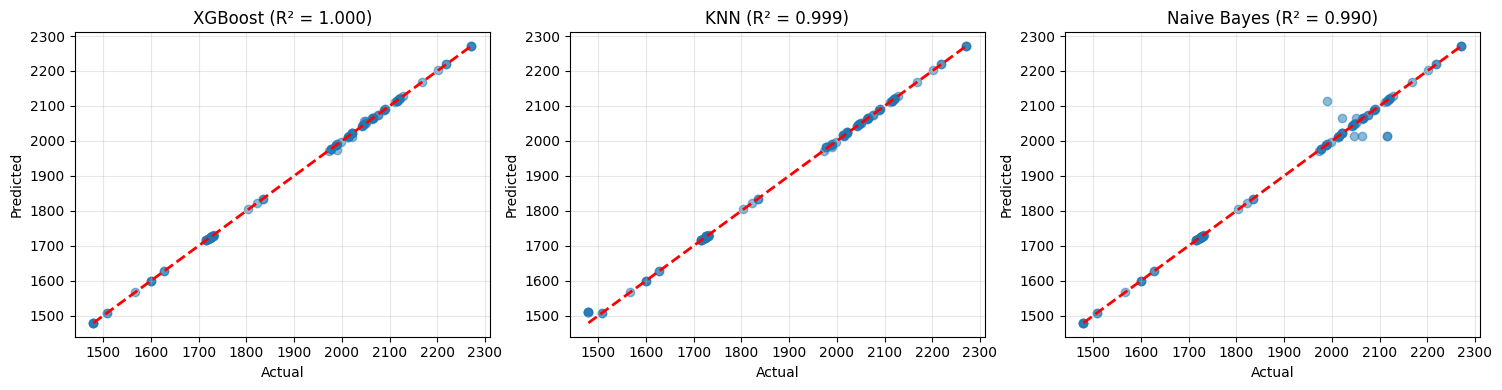


✓ Models trained and evaluated!


In [4]:
if df is not None:
    print("="*80)
    print("TRAINING MACHINE LEARNING MODELS")
    print("="*80)
    
    X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)
    print(f"\nTraining set: {len(X_train)} | Test set: {len(X_test)}")
    
    models = {}
    results = {}
    predictions_list = {}
    
    # 1. XGBoost Regressor
    print("\n[1/3] Training XGBoost Regressor...")
    xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    models['XGBoost'] = xgb
    predictions_list['XGBoost'] = y_pred_xgb
    results['XGBoost'] = {
        'R²': r2_score(y_test, y_pred_xgb),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        'MAE': mean_absolute_error(y_test, y_pred_xgb)
    }
    
    # Cross-validation
    cv_scores_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2')
    print(f"  5-Fold CV Score: {np.mean(cv_scores_xgb):.4f} ± {np.std(cv_scores_xgb):.4f}")
    
    # 2. K-Nearest Neighbors Regressor
    print("[2/3] Training KNN Regressor (k=5)...")
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    models['KNN'] = knn
    predictions_list['KNN'] = y_pred_knn
    results['KNN'] = {
        'R²': r2_score(y_test, y_pred_knn),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_knn)),
        'MAE': mean_absolute_error(y_test, y_pred_knn)
    }
    
    cv_scores_knn = cross_val_score(knn, X_train, y_train, cv=5, scoring='r2')
    print(f"  5-Fold CV Score: {np.mean(cv_scores_knn):.4f} ± {np.std(cv_scores_knn):.4f}")
    
    # 3. Gaussian Naive Bayes
    print("[3/3] Training Gaussian Naive Bayes...")
    gnb = GaussianNB()
    gnb.fit(X_train, y_train)
    y_pred_gnb = gnb.predict(X_test)
    models['Naive Bayes'] = gnb
    predictions_list['Naive Bayes'] = y_pred_gnb
    results['Naive Bayes'] = {
        'R²': r2_score(y_test, y_pred_gnb),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gnb)),
        'MAE': mean_absolute_error(y_test, y_pred_gnb)
    }
    
    cv_scores_gnb = cross_val_score(gnb, X_train, y_train, cv=5, scoring='r2')
    print(f"  5-Fold CV Score: {np.mean(cv_scores_gnb):.4f} ± {np.std(cv_scores_gnb):.4f}")
    
    # Display results
    results_df = pd.DataFrame(results).T
    print("\n" + "="*80)
    print("MODEL PERFORMANCE COMPARISON")
    print("="*80)
    print(results_df.round(4))
    
    best_model = results_df['R²'].idxmax()
    print(f"\n🏆 Best Model: {best_model} (R² = {results_df.loc[best_model, 'R²']:.4f})")
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    models_to_plot = [('XGBoost', y_pred_xgb), ('KNN', y_pred_knn), ('Naive Bayes', y_pred_gnb)]
    
    for idx, (model_name, y_pred) in enumerate(models_to_plot):
        ax = axes[idx]
        ax.scatter(y_test, y_pred, alpha=0.5)
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{model_name} (R² = {results_df.loc[model_name, "R²"]:.3f})')
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Models trained and evaluated!")


## Section 5: Feature Importance Analysis

FEATURE IMPORTANCE

XGBoost Feature Importance:
             Feature  XGBoost_Importance
0  Amount_of_chicken            0.699193
4    Light_Intensity            0.088991
2        Temperature            0.085753
5              Noise            0.083682
1  Amount_of_Feeding            0.031282
3           Humidity            0.011099


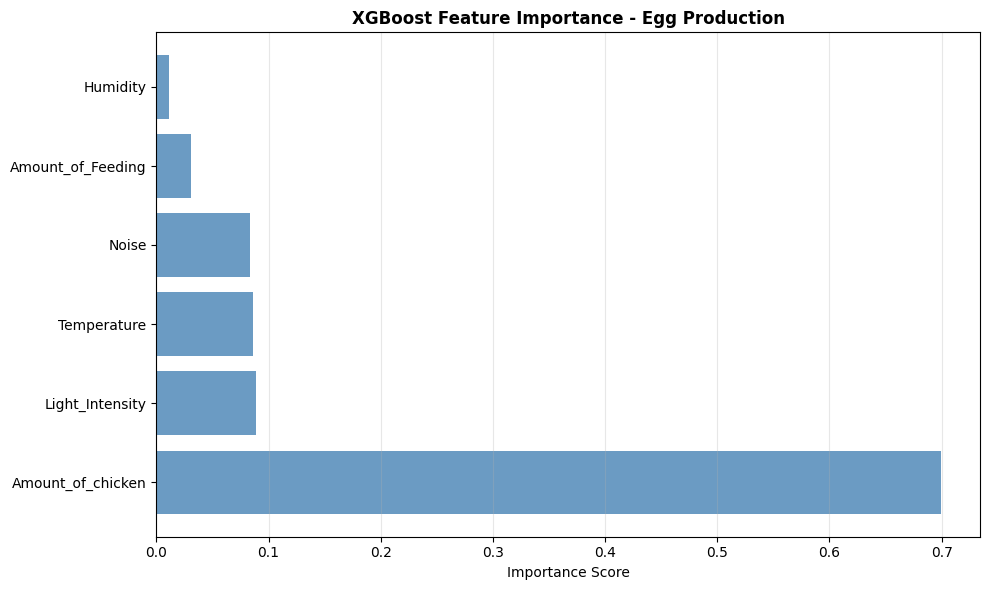


✓ Feature importance analyzed!


In [5]:
if df is not None:
    print("="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)
    
    # XGBoost feature importance
    xgb_importance = xgb.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': criteria_columns,
        'XGBoost_Importance': xgb_importance
    }).sort_values('XGBoost_Importance', ascending=False)
    
    print("\nXGBoost Feature Importance:")
    print(importance_df)
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['Feature'], importance_df['XGBoost_Importance'], color='steelblue', alpha=0.8)
    ax.set_xlabel('Importance Score')
    ax.set_title('XGBoost Feature Importance - Egg Production', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Feature importance analyzed!")


## Section 6: Summary & Conclusions

In [6]:
if df is not None:
    print("\n" + "="*80)
    print("EGG PRODUCTION ANALYSIS - SUMMARY")
    print("="*80)
    
    print("\n📊 MCDM FRAMEWORK:")
    print(f"  ✓ Environmental factors analyzed: {len(criteria_columns)}")
    print(f"  ✓ Weight methods: 4 (STD, Entropy, CRITIC, MEREC) + Compromise")
    print(f"  ✓ Total observations: {len(df_mcdm)}")
    
    print("\n🤖 MACHINE LEARNING MODELS:")
    print(f"  ✓ XGBoost R²: {results_df.loc['XGBoost', 'R²']:.4f}")
    print(f"  ✓ KNN R²: {results_df.loc['KNN', 'R²']:.4f}")
    print(f"  ✓ Naive Bayes R²: {results_df.loc['Naive Bayes', 'R²']:.4f}")
    print(f"  ✓ Best Model: {best_model}")
    
    print("\n🎯 KEY INSIGHTS:")
    print(f"  1. Best performing model achieves R² = {results_df.loc[best_model, 'R²']:.4f}")
    print(f"  2. Top factor: {importance_df.iloc[0]['Feature']}")
    print(f"  3. MCDM weights identify critical environmental criteria")
    print(f"  4. ML models predict egg production with ~{results_df.loc[best_model, 'RMSE']:.2f} units RMSE")
    
    print("\n✓ ANALYSIS COMPLETE!")
    print("="*80)
else:
    print("\n⚠️  Please provide Egg_Production.csv file to run analysis")
    print("Dataset source: https://www.kaggle.com/datasets/...")



EGG PRODUCTION ANALYSIS - SUMMARY

📊 MCDM FRAMEWORK:
  ✓ Environmental factors analyzed: 6
  ✓ Weight methods: 4 (STD, Entropy, CRITIC, MEREC) + Compromise
  ✓ Total observations: 481

🤖 MACHINE LEARNING MODELS:
  ✓ XGBoost R²: 0.9999
  ✓ KNN R²: 0.9991
  ✓ Naive Bayes R²: 0.9904
  ✓ Best Model: XGBoost

🎯 KEY INSIGHTS:
  1. Best performing model achieves R² = 0.9999
  2. Top factor: Amount_of_chicken
  3. MCDM weights identify critical environmental criteria
  4. ML models predict egg production with ~2.35 units RMSE

✓ ANALYSIS COMPLETE!
